#Support Vector Machine (Supervised Machine Learning)
##Support Vector Machine is a supervised machine learning algorithm used primarily for:

**Classification (e.g., spam detection, image recognition)**

**Regression (SVR – Support Vector Regression)**

In [2]:
from sklearn.datasets import load_digits
import pandas as pd
import matplotlib.pyplot as plt

##Load the dataset

In [3]:
digits = load_digits()

## Explore the Structure of the Digits Dataset


In [4]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

## View and Convert the Digits Dataset to a Pandas DataFrame for better visualization


In [5]:
print(digits.data)
df1 = pd.DataFrame(digits.data)
df1

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


##Or you can do this

In [6]:
df = pd.DataFrame(digits.data, columns = digits.feature_names)

df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


##Also append the target column to the dataframe

In [7]:
df["Target"] = digits.target

df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,Target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


##Import essential libraries

In [8]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


## Define Features and Target, then Perform Train-Test Split


In [9]:
X = df.drop('Target' , axis = 'columns')
y = df['Target']

#X_train, X_test, y_train, y_test = train_test_split(digits.data,digits.target, test_size = 0.2)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3)

## Train and Evaluate the Support Vector Classifier (SVC)


In [10]:
model = SVC()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9777777777777777

In [11]:
result = model.predict(X_test)

result

array([4, 4, 5, 8, 4, 9, 3, 2, 7, 8, 0, 6, 2, 9, 8, 2, 2, 5, 2, 1, 7, 6,
       9, 2, 1, 1, 4, 1, 7, 1, 0, 2, 2, 6, 9, 8, 4, 6, 4, 1, 2, 9, 9, 9,
       0, 6, 3, 7, 8, 3, 1, 9, 6, 4, 3, 0, 9, 4, 8, 8, 9, 0, 5, 4, 4, 5,
       2, 2, 3, 4, 2, 8, 9, 9, 0, 5, 3, 8, 5, 1, 8, 6, 4, 4, 2, 0, 4, 2,
       7, 0, 3, 2, 6, 7, 0, 9, 1, 0, 7, 4, 6, 8, 2, 9, 4, 1, 3, 1, 4, 3,
       4, 9, 0, 3, 7, 4, 7, 8, 2, 4, 1, 7, 5, 1, 6, 8, 2, 0, 3, 6, 0, 0,
       1, 1, 7, 3, 5, 4, 8, 6, 6, 3, 7, 8, 9, 2, 5, 6, 0, 6, 9, 1, 4, 4,
       5, 5, 1, 2, 6, 3, 1, 6, 0, 4, 0, 2, 9, 4, 2, 7, 2, 2, 8, 9, 4, 9,
       7, 8, 6, 5, 5, 6, 2, 3, 9, 6, 7, 6, 3, 7, 9, 3, 3, 3, 7, 6, 8, 0,
       2, 0, 9, 5, 2, 8, 4, 2, 6, 3, 4, 2, 3, 9, 4, 9, 1, 7, 0, 1, 2, 2,
       7, 6, 8, 8, 0, 5, 6, 1, 8, 0, 7, 2, 8, 5, 7, 8, 7, 1, 5, 2, 2, 2,
       5, 4, 7, 8, 0, 4, 0, 1, 1, 8, 3, 7, 0, 0, 3, 0, 5, 9, 7, 0, 5, 7,
       9, 3, 3, 6, 8, 0, 5, 9, 8, 1, 6, 8, 7, 9, 0, 8, 7, 6, 7, 7, 9, 6,
       9, 3, 5, 3, 7, 0, 0, 1, 9, 7, 0, 1, 1, 8, 1,

##Plot the digits images to better visualize them

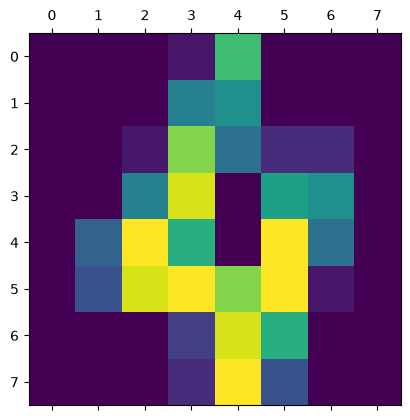

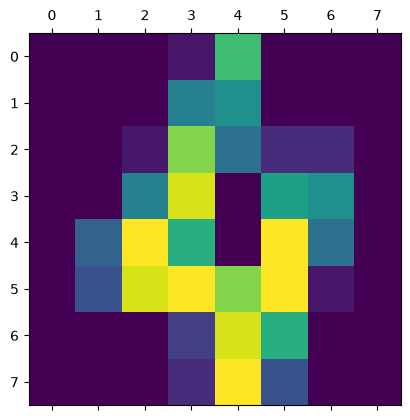

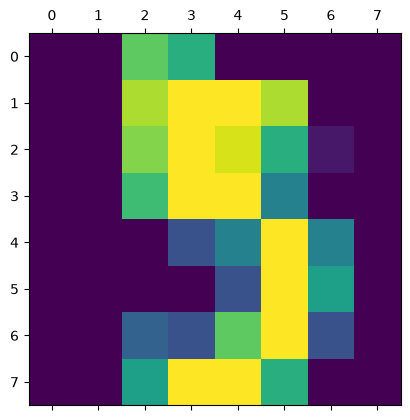

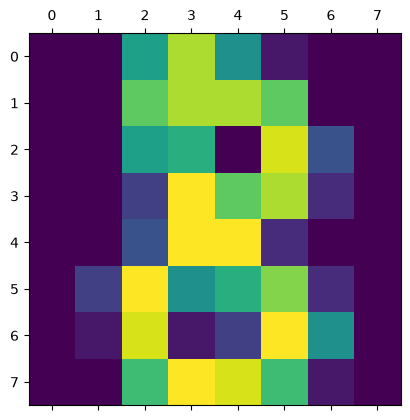

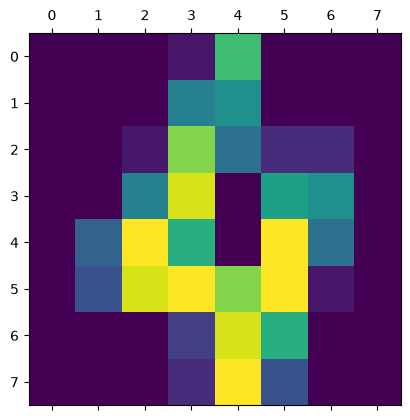

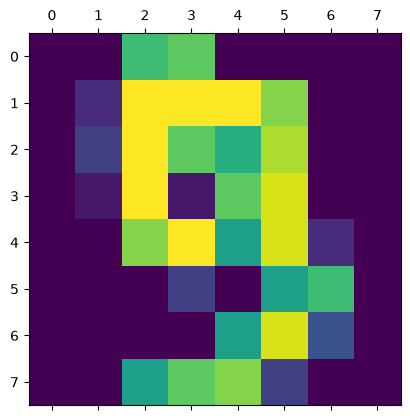

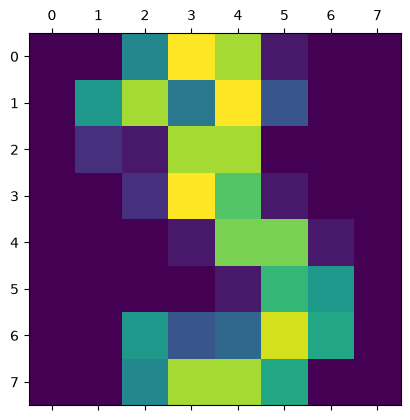

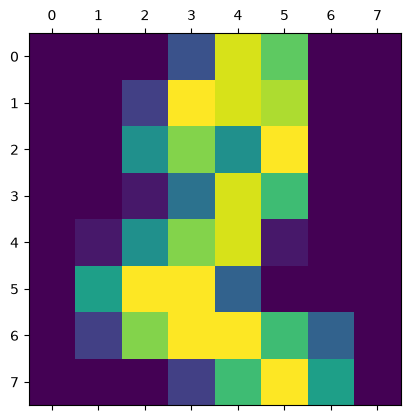

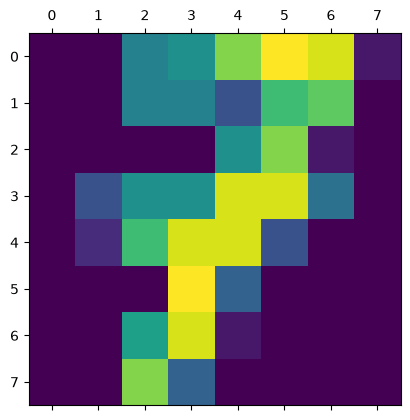

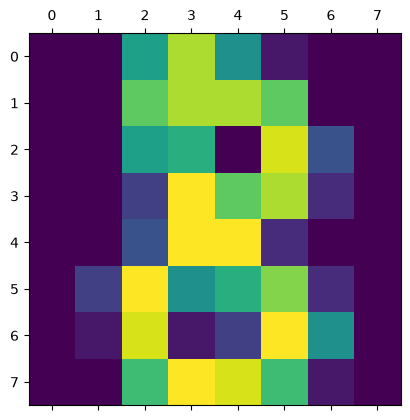

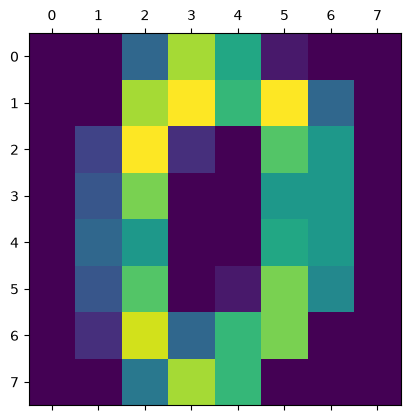

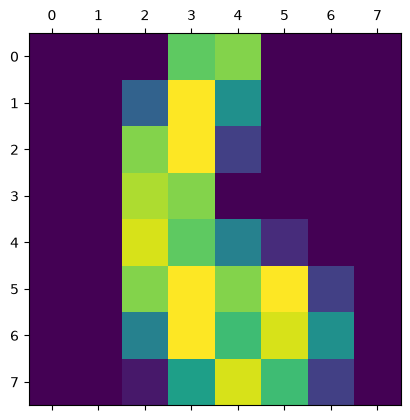

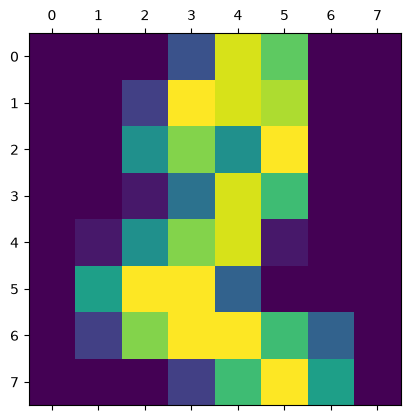

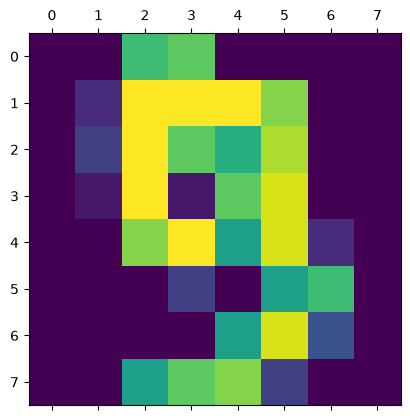

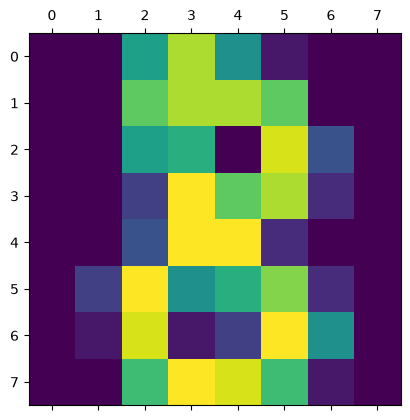

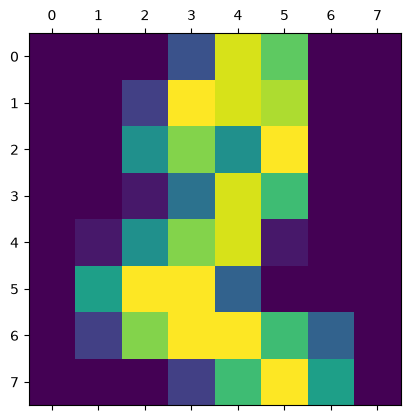

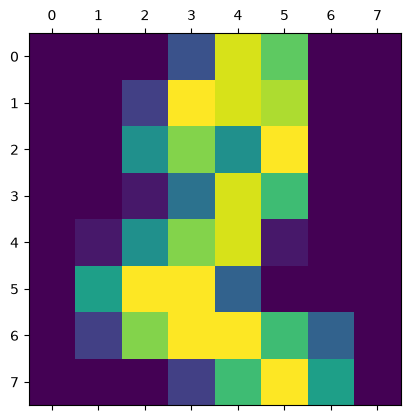

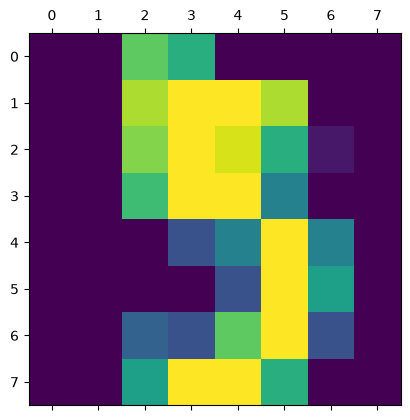

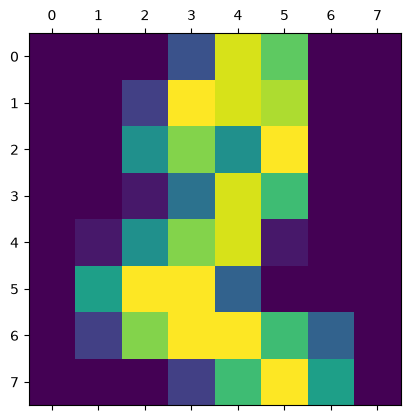

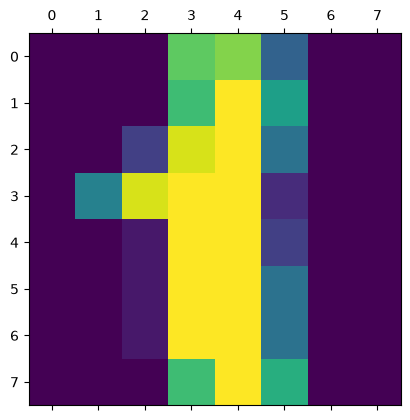

In [14]:
for i in range(20):
    plt.matshow(digits.images[result[i]])

## Excellent, now try changing the test size and train the model on Support Vector Classifier to identify how test and train size variation can increase/decrease model accuracy.

In [15]:
#Start here
test_sizes = [0.1, 0.2, 0.3, 0.4]

for size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=size, random_state=42)

In [17]:
    model = SVC()
    model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
    accuracy = model.score(X_test, y_test)

In [20]:
    print("Test Size:", size)
    print("Train Size:", 1-size)
    print("Accuracy:", accuracy)
    print("----------------------")

Test Size: 0.4
Train Size: 0.6
Accuracy: 0.9860917941585535
----------------------


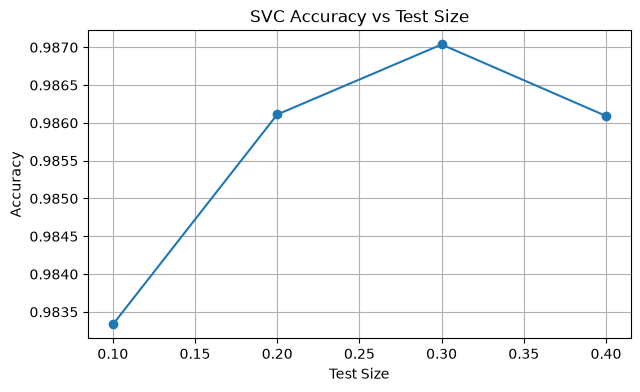

In [26]:
test_sizes = [0.1, 0.2, 0.3, 0.4]
accuracy = []

for size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=size, random_state=42
    )

    model = SVC()
    model.fit(X_train, y_train)

    accuracy.append(model.score(X_test, y_test))

plt.figure(figsize=(7,4))
plt.plot(test_sizes, accuracy, marker='o')
plt.xlabel("Test Size")
plt.ylabel("Accuracy")
plt.title("SVC Accuracy vs Test Size")
plt.grid(True)
plt.show()